# Project Title
## Cat vs Dog Classification using MobileNetV2 (Transfer Learning)



## 📌 Project Description

This project focuses on building a deep learning model to classify images as either **Cat** or **Dog** using **Transfer Learning** with the pre-trained **MobileNetV2** architecture. Instead of training a convolutional neural network from scratch, MobileNetV2 leverages knowledge learned from the ImageNet dataset, enabling faster training, improved accuracy, and better generalization.

The project follows a complete deep learning pipeline, including dataset preparation, image preprocessing, data augmentation, model training, evaluation, and prediction. Images are resized and normalized before being fed into the model, and performance is assessed using metrics such as **Accuracy, Precision, Recall, F1-Score, and Confusion Matrix**.

Finally, the trained model is deployed using a **Flask** web application, allowing users to upload an image and receive real-time predictions. This project demonstrates practical applications of **Computer Vision**, **Convolutional Neural Networks (CNNs)**, **Transfer Learning**, and **Deep Learning** for binary image classification.

# Imports Required Libraries & Config

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

DATASET_PATH = "/kaggle/input/notebooks/gpreda/cats-or-dogs-using-cnn-with-transfer-learning/train"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
CLASS_NAMES = ["cat", "dog"]

tf.random.set_seed(SEED)
np.random.seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


# Load Dataset

In [3]:
def build_dataframe(dataset_path):
    filepaths, labels = [], []
    subdirs = [d for d in os.listdir(dataset_path)
               if os.path.isdir(os.path.join(dataset_path, d))]

    if len(subdirs) >= 2:
        for sub in subdirs:
            sub_path = os.path.join(dataset_path, sub)
            label = "dog" if "dog" in sub.lower() else "cat"
            for fname in os.listdir(sub_path):
                if fname.lower().endswith((".jpg", ".jpeg", ".png")):
                    filepaths.append(os.path.join(sub_path, fname))
                    labels.append(label)
    else:
        for fname in os.listdir(dataset_path):
            if fname.lower().endswith((".jpg", ".jpeg", ".png")):
                label = "dog" if "dog" in fname.lower() else "cat"
                filepaths.append(os.path.join(dataset_path, fname))
                labels.append(label)

    return pd.DataFrame({"filepath": filepaths, "label": labels})

df = build_dataframe(DATASET_PATH)
print("Total images found:", len(df))
df.head()

Total images found: 25000


,filepath,label
0,/kaggle/input/notebooks/gpreda/cats-or-dogs-us...,cat
1,/kaggle/input/notebooks/gpreda/cats-or-dogs-us...,dog
2,/kaggle/input/notebooks/gpreda/cats-or-dogs-us...,dog
3,/kaggle/input/notebooks/gpreda/cats-or-dogs-us...,dog
4,/kaggle/input/notebooks/gpreda/cats-or-dogs-us...,dog


# STEP 1 — Perform EDA

label
cat    12500
dog    12500
Name: count, dtype: int64


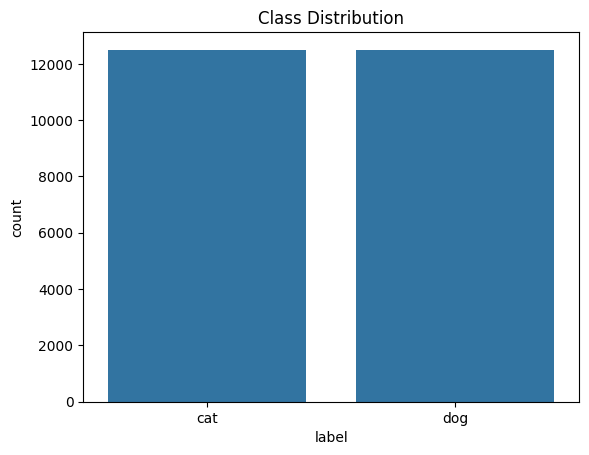

In [4]:
# Sub-step 1.1: Class distribution
print(df["label"].value_counts())
sns.countplot(data=df, x="label")
plt.title("Class Distribution")
plt.show()

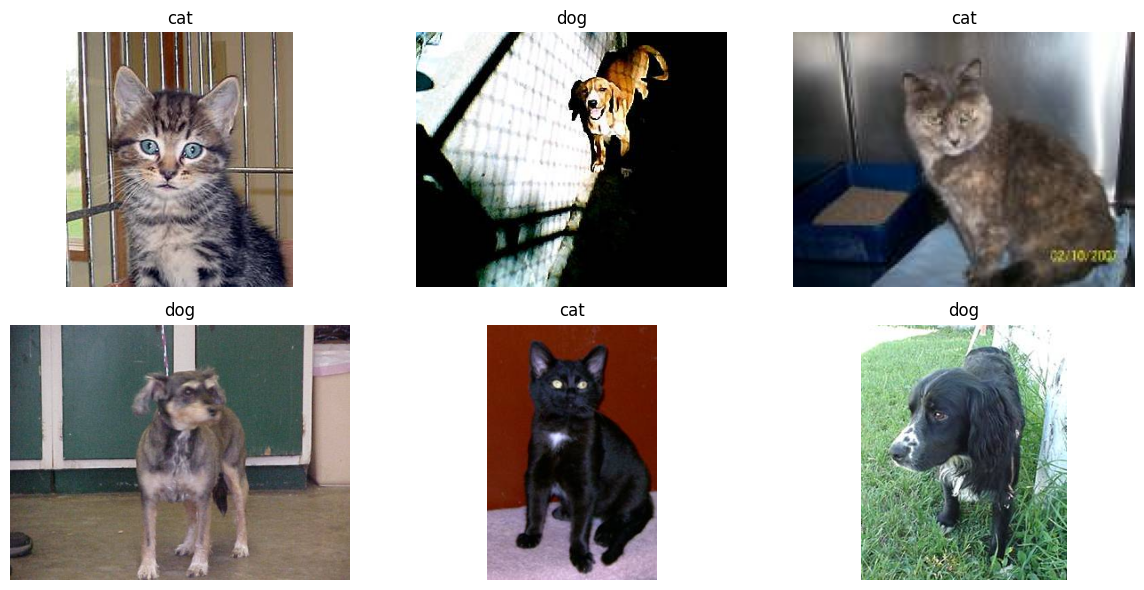

In [5]:
# Sub-step 1.2: Sample images
def show_sample_images(df, n=6):
    plt.figure(figsize=(12, 6))
    sample = df.sample(n, random_state=SEED)
    for i, (_, row) in enumerate(sample.iterrows()):
        img = cv2.imread(row["filepath"])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(2, n // 2, i + 1)
        plt.imshow(img)
        plt.title(row["label"])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_sample_images(df)

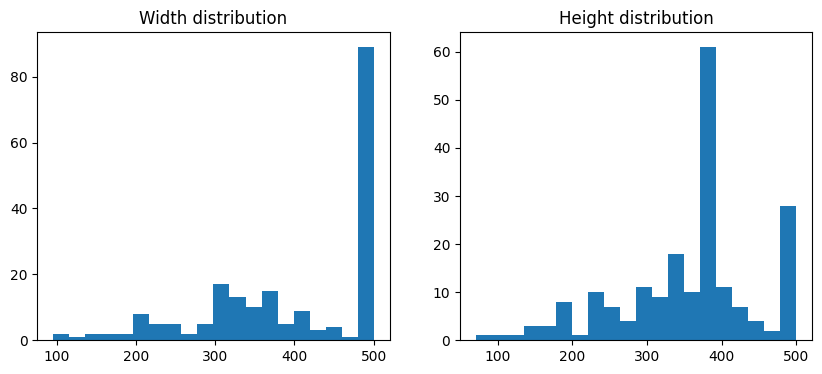

In [6]:
# Sub-step 1.3: Image size distribution
widths, heights = [], []
for fp in df["filepath"].sample(min(200, len(df)), random_state=SEED):
    img = cv2.imread(fp)
    if img is not None:
        h, w = img.shape[:2]
        widths.append(w)
        heights.append(h)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1); plt.hist(widths, bins=20); plt.title("Width distribution")
plt.subplot(1, 2, 2); plt.hist(heights, bins=20); plt.title("Height distribution")
plt.show()

# STEP 4 — Preprocess Images

In [7]:
# Sub-step 4.1: Encode labels
df["label_id"] = df["label"].map({"cat": 0, "dog": 1})

# Sub-step 4.2: Preprocessing function
def load_and_preprocess_image(filepath, label):
    image = tf.io.read_file(filepath)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, IMG_SIZE)
    image = preprocess_input(image)
    return image, label

# STEP 5 — Apply Data Augmentation

In [8]:
# Sub-step 5.1: Augmentation layer
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.1),
    layers.RandomTranslation(0.1, 0.1),
], name="data_augmentation")

I0000 00:00:1785409779.268028     104 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1785409779.271261     104 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


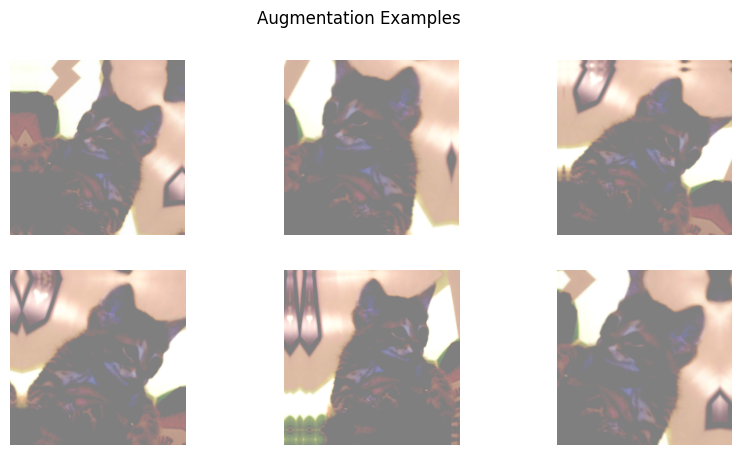

In [9]:
# Sub-step 5.2: Visualize augmentation
sample_fp = df["filepath"].iloc[0]
sample_img, _ = load_and_preprocess_image(sample_fp, 0)
sample_img_batch = tf.expand_dims(sample_img, 0)

plt.figure(figsize=(10, 5))
for i in range(6):
    aug_img = data_augmentation(sample_img_batch, training=True)
    plt.subplot(2, 3, i + 1)
    display_img = (aug_img[0].numpy() + 1) / 2.0
    plt.imshow(np.clip(display_img, 0, 1))
    plt.axis("off")
plt.suptitle("Augmentation Examples")
plt.show()

# STEP 6 — Split Dataset

In [10]:
# Sub-step 6.1: Train/Val/Test split
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df["label_id"], random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df["label_id"], random_state=SEED)

print("Train size:", len(train_df))
print("Val size:", len(val_df))
print("Test size:", len(test_df))

Train size: 17500
Val size: 3750
Test size: 3750


In [11]:
# Sub-step 6.2: Build tf.data pipelines
def make_dataset(df, training=False):
    ds = tf.data.Dataset.from_tensor_slices((df["filepath"].values, df["label_id"].values))
    ds = ds.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.shuffle(1000, seed=SEED)
    ds = ds.batch(BATCH_SIZE)
    if training:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                    num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df, training=False)
test_ds = make_dataset(test_df, training=False)

# STEP 10 — Load & Freeze Base Model

In [12]:
# Sub-step 10.1: Load pretrained MobileNetV2
base_model = MobileNetV2(input_shape=IMG_SIZE + (3,), include_top=False, weights="imagenet")

# Sub-step 10.2: Freeze
base_model.trainable = False
print("Base model layers:", len(base_model.layers))

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base model layers: 154


# STEP 11 — Add Custom Classification Head

In [13]:
inputs = keras.Input(shape=IMG_SIZE + (3,))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D(name="gap")(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1, activation="sigmoid", name="predictions")(x)

model = keras.Model(inputs, outputs, name="mobilenetv2_cats_dogs")
model.summary()

Model: "mobilenetv2_cats_dogs"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# STEP 12 — Compile the Model

In [14]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", keras.metrics.AUC(name="auc")]
)

# STEP 13 — Train the Classifier

In [15]:
# Sub-step 13.1: Callbacks
early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)
checkpoint = keras.callbacks.ModelCheckpoint("best_model_head.keras", monitor="val_accuracy", save_best_only=True)
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6)

# Sub-step 13.2: Fit
EPOCHS = 15
history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS,
                     callbacks=[early_stop, checkpoint, reduce_lr])

Epoch 1/15


2026-07-30 11:10:04.714731: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-30 11:10:04.853005: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1785409807.632172     173 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


546/547 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - accuracy: 0.8074 - auc: 0.8939 - loss: 0.4062

2026-07-30 11:12:16.225091: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-30 11:12:16.362740: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - accuracy: 0.8074 - auc: 0.8939 - loss: 0.4061

2026-07-30 11:12:38.543204: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-30 11:12:38.680694: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


547/547 ━━━━━━━━━━━━━━━━━━━━ 176s 281ms/step - accuracy: 0.8328 - auc: 0.9196 - loss: 0.3585 - val_accuracy: 0.9800 - val_auc: 0.9967 - val_loss: 0.0714 - learning_rate: 0.0010
Epoch 2/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 120s 216ms/step - accuracy: 0.8527 - auc: 0.9374 - loss: 0.3157 - val_accuracy: 0.9837 - val_auc: 0.9978 - val_loss: 0.0541 - learning_rate: 0.0010
Epoch 3/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 120s 216ms/step - accuracy: 0.8601 - auc: 0.9416 - loss: 0.3051 - val_accuracy: 0.9827 - val_auc: 0.9977 - val_loss: 0.0568 - learning_rate: 0.0010
Epoch 4/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 122s 219ms/step - accuracy: 0.8582 - auc: 0.9424 - loss: 0.3026 - val_accuracy: 0.9853 - val_auc: 0.9981 - val_loss: 0.0454 - learning_rate: 0.0010
Epoch 5/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 121s 218ms/step - accuracy: 0.8619 - auc: 0.9459 - loss: 0.2927 - val_accuracy: 0.9845 - val_auc: 0.9981 - val_loss: 0.0457 - learning_rate: 0.0010
Epoch 6/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 122s 219ms/step - accuracy: 0.8

# STEP 14 — Evaluate Performance

118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.9845 - auc: 0.9990 - loss: 0.0409
Test Loss: 0.0409 | Test Accuracy: 0.9845 | Test AUC: 0.9990
118/118 ━━━━━━━━━━━━━━━━━━━━ 12s 64ms/step
              precision    recall  f1-score   support

         cat       0.99      0.98      0.98      1875
         dog       0.98      0.99      0.98      1875

    accuracy                           0.98      3750
   macro avg       0.98      0.98      0.98      3750
weighted avg       0.98      0.98      0.98      3750



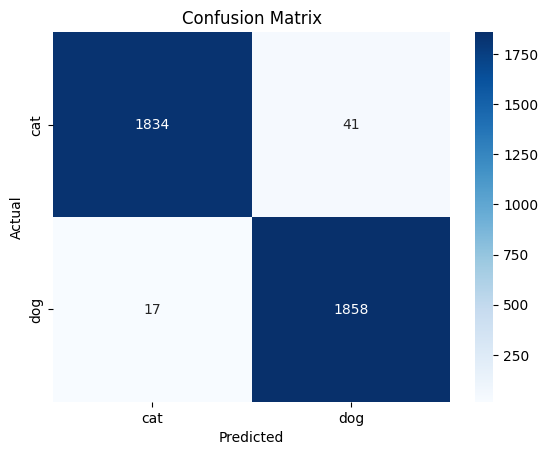

In [16]:
# Sub-step 14.1: Test metrics
test_loss, test_acc, test_auc = model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f} | Test AUC: {test_auc:.4f}")

# Sub-step 14.2: Predictions + report
y_true = test_df["label_id"].values
y_pred_prob = model.predict(test_ds).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# Sub-step 14.3: Confusion matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion Matrix")
plt.show()

# STEP 15 — Visualize Results

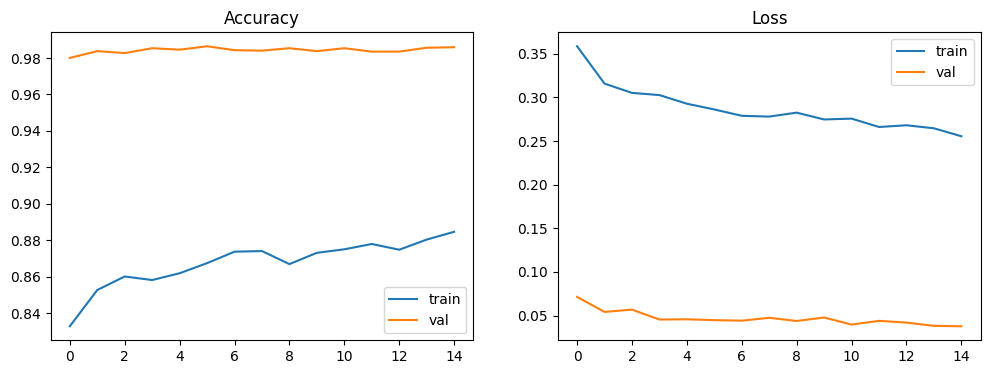

In [17]:
# Sub-step 15.1: Accuracy/Loss curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["accuracy"], label="train")
axes[0].plot(history.history["val_accuracy"], label="val")
axes[0].set_title("Accuracy"); axes[0].legend()
axes[1].plot(history.history["loss"], label="train")
axes[1].plot(history.history["val_loss"], label="val")
axes[1].set_title("Loss"); axes[1].legend()
plt.show()

2026-07-30 11:41:37.540605: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-30 11:41:37.676525: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


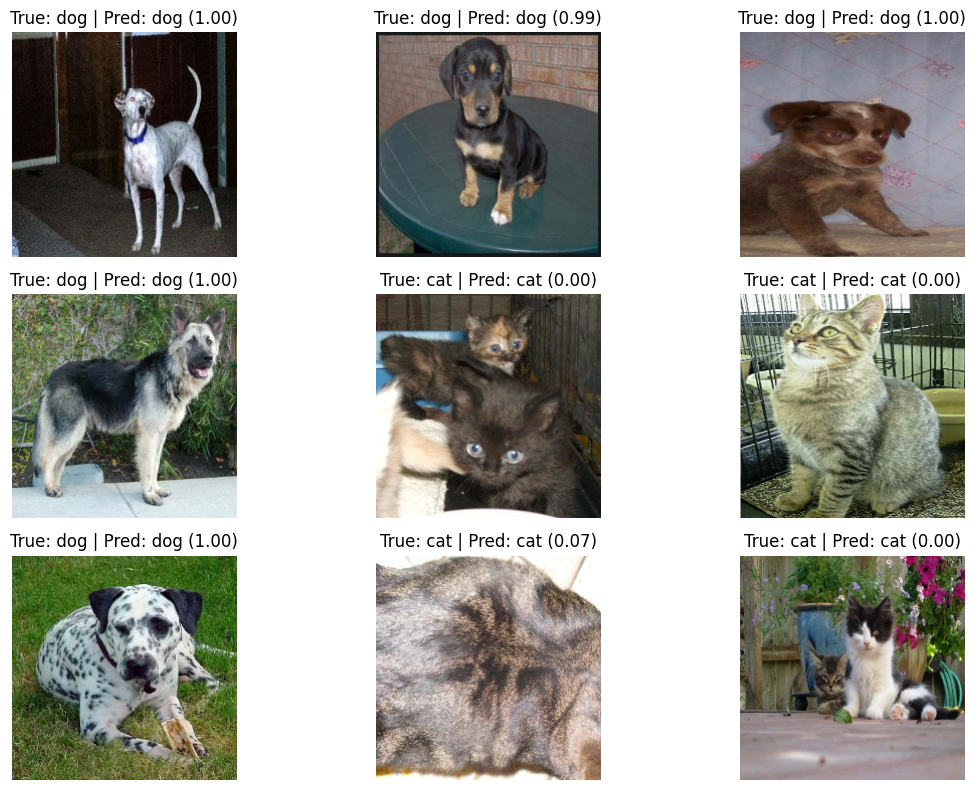

In [18]:
# Sub-step 15.2: Sample predictions
plt.figure(figsize=(12, 8))
sample_test = test_df.sample(9, random_state=SEED).reset_index(drop=True)
for i, row in sample_test.iterrows():
    img, _ = load_and_preprocess_image(row["filepath"], row["label_id"])
    pred = model.predict(tf.expand_dims(img, 0), verbose=0)[0][0]
    pred_label = CLASS_NAMES[int(pred > 0.5)]
    display_img = (img.numpy() + 1) / 2.0
    plt.subplot(3, 3, i + 1)
    plt.imshow(np.clip(display_img, 0, 1))
    plt.title(f"True: {row['label']} | Pred: {pred_label} ({pred:.2f})")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [20]:
# Sub-step 17.1: Grad-CAM setup
def get_last_conv_layer_name(model):
    for layer in reversed(base_model.layers):
        if isinstance(layer, layers.Conv2D) or "conv" in layer.name.lower():
            return layer.name
    raise ValueError("No conv layer found in base model.")

LAST_CONV_LAYER = get_last_conv_layer_name(model)
print("Using last conv layer for Grad-CAM:", LAST_CONV_LAYER)

grad_model = keras.Model(
    inputs=model.input,
    outputs=[base_model.get_layer(LAST_CONV_LAYER).output, model.output]
)

def make_gradcam_heatmap(img_array, grad_model):
    with tf.GradientTape() as tape:
        conv_outputs, preds = grad_model(img_array)
        class_channel = preds[:, 0]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

Using last conv layer for Grad-CAM: Conv_1_bn


In [21]:
# Sub-step 17.2: Overlay heatmap on image
def display_gradcam(filepath, heatmap, alpha=0.4):
    img = cv2.imread(filepath)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)

    heatmap_resized = cv2.resize(heatmap, IMG_SIZE)
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    overlay = np.uint8(heatmap_color * alpha + img * (1 - alpha))

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1); plt.imshow(img); plt.title("Original"); plt.axis("off")
    plt.subplot(1, 2, 2); plt.imshow(overlay); plt.title("Grad-CAM"); plt.axis("off")
    plt.show()

In [19]:
# Sub-step 17.3: Run on a sample test image
sample_fp = test_df["filepath"].iloc[0]
sample_img, _ = load_and_preprocess_image(sample_fp, 0)
sample_img_batch = tf.expand_dims(sample_img, 0)

heatmap = make_gradcam_heatmap(sample_img_batch, grad_model)
display_gradcam(sample_fp, heatmap)

NameError: name 'make_gradcam_heatmap' is not defined

In [22]:
def predict_image(filepath, model, threshold=0.5):
    img, _ = load_and_preprocess_image(filepath, 0)
    img_batch = tf.expand_dims(img, 0)
    prob = model.predict(img_batch, verbose=0)[0][0]
    label = "dog" if prob > threshold else "cat"
    confidence = prob if prob > threshold else 1 - prob
    return label, float(confidence)

new_image_path = test_df["filepath"].iloc[1]  # replace with any image path
pred_label, pred_conf = predict_image(new_image_path, model)
print(f"Prediction: {pred_label} (confidence: {pred_conf:.2%})")

Prediction: cat (confidence: 100.00%)


In [23]:
# Sub-step 19.1: Save in Keras format
model.save("cats_dogs_mobilenetv2_final.keras")

# Sub-step 19.2: Save as SavedModel for deployment
model.export("cats_dogs_mobilenetv2_savedmodel")

print("Model saved successfully.")

INFO:tensorflow:Assets written to: cats_dogs_mobilenetv2_savedmodel/assets


INFO:tensorflow:Assets written to: cats_dogs_mobilenetv2_savedmodel/assets


Saved artifact at 'cats_dogs_mobilenetv2_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_160')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  132784955571088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132784955571856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132784955571280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132784955571664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132784955572048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132783497545104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132783497546256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132783497546064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132783497545680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132783497546832: TensorSpec(shape=(), dtype=tf.resource, name=No